# Civil Defense in Brazil (2020–2022) — Full Data Analysis Project

A complete, from-scratch analysis of the Brazilian Civil Defense complaints dataset
(`civil_defense_br.csv`). The Power BI dashboard you shared earlier was used only as
a starting reference for the topic — this notebook is a broader, independent project:
full cleaning, exploratory analysis, a key domain-specific finding (COVID-19 dominates
this dataset), a predictive model, and a short-term forecast.

**Contents**
1. Data loading & overview
2. Data cleaning
3. Data quality note — why this dataset is not just "natural disasters"
4. Exploratory analysis (temporal, geographic, disaster type, human impact,
   infrastructure damage, environment, economic loss vs. expenditure, correlations)
5. Key insights
6. Predictive model — will a complaint be validated?
7. Short-term forecast of monthly complaint volume
8. Exporting a clean dataset


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

plt.rcParams["figure.facecolor"] = "#0d1b0f"
plt.rcParams["axes.facecolor"] = "#0d1b0f"
plt.rcParams["savefig.facecolor"] = "#0d1b0f"
plt.rcParams["text.color"] = "#e8f5e9"
plt.rcParams["axes.labelcolor"] = "#e8f5e9"
plt.rcParams["xtick.color"] = "#e8f5e9"
plt.rcParams["ytick.color"] = "#e8f5e9"
plt.rcParams["axes.edgecolor"] = "#2e5c34"
plt.rcParams["font.size"] = 11

GREENS = ["#00c853", "#43a047", "#81c784", "#c8e6c9", "#1b5e20", "#66bb6a", "#a5d6a7"]
pd.set_option("display.max_columns", 60)


## 2. Load and inspect the raw data

In [2]:
df_raw = pd.read_csv("civil_defense_br.csv")
print("Shape:", df_raw.shape)
df_raw.head(3)


Shape: (29602, 52)


,Date,State,City,Complaint,Status,Population,Dead,Enjuried,Ill,Homeless,Displaced,Lost,Other_affected,Homes_damaged,Homes_destroyed,Home_value,Public_health_places_damaged,Public_health_places_destroyed,Public_health_places_value,Public_schools_damaged,Public_schools_destroyed,Public_schools_value,Other_public_installations_damaged,Other_public_installations_destroyed,Other_public_installations_value,Public_use installations_damaged,Public_use installations_destroyed,Public_use installations_value,Infraestructure_damaged,Infraestructure_daestroyed,Infraestructure_value,Water_contamination,Air_poluition,Soil_contamination,Water_exhaustion,Forest_fire,Medical_expedenture,Potable_water_expedenture,Sanitation_expedenture,City_cleaning_expedenture,Pest_control_expedenture,Electric_energy_expedenture,Telecom_expedenture,Transportation_expedenture,Fuel_expedenture,Public_safety_expedenture,Schooling_expedenture,Agriculture_loss,Livestocking_loss,Industry_loss,Commerce_loss,Service_loss
0,2022-12-31,MG,Cataguases,13214 - Tempestade Local/Convectiva - Chuvas I...,Register,69810,0,0,0,0,0,0,0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-12-30,RS,Paraiso do Sul,14110 - Estiagem,Register,7336,0,0,0,0,0,0,420,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0.1,0.0,0.0,0.05,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023-01-02,RS,Taquarucu do Sul,14110 - Estiagem,Register,2970,0,0,0,0,0,0,1812,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0.0,0.0,0.0,0.0,0.40,0.0,0.0,30500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12851327.0,7527500.0,0.0,0.0,0.0


In [3]:
df_raw.describe().T.head(15)


,count,mean,std,min,25%,50%,75%,max
Population,29602.0,5.154099e+04,2.623898e+05,0.0,6321.0,13511.0,29075.0,1.124437e+07
Dead,29602.0,1.540034e+01,2.966995e+02,0.0,0.0,0.0,0.0,2.249700e+04
Enjuried,29602.0,8.838254e+00,3.215034e+02,0.0,0.0,0.0,0.0,3.110800e+04
Ill,29602.0,3.504324e+02,7.281820e+03,0.0,0.0,0.0,0.0,3.329500e+05
Homeless,29602.0,8.372137e+00,1.044642e+02,0.0,0.0,0.0,0.0,5.440000e+03
Displaced,29602.0,4.684542e+01,7.634593e+02,0.0,0.0,0.0,0.0,9.864400e+04
Lost,29602.0,1.669043e+00,1.636354e+02,0.0,0.0,0.0,0.0,2.000000e+04
Other_affected,29602.0,4.569029e+03,1.231534e+05,0.0,0.0,0.0,833.5,1.726317e+07
Homes_damaged,29602.0,2.481842e+01,4.817731e+02,0.0,0.0,0.0,0.0,4.500000e+04
Homes_destroyed,29602.0,1.027431e+00,2.534766e+01,0.0,0.0,0.0,0.0,2.200000e+03


## 3. Data cleaning

In [4]:
df = df_raw.drop_duplicates().copy()
print("After dropping duplicates:", len(df), "(-", len(df_raw) - len(df), ")")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["YearMonth"] = df["Date"].dt.to_period("M")

before = len(df)
df = df[df["Year"].isin([2020, 2021, 2022])].copy()
print("After keeping 2020-2022:", len(df), "(-", before - len(df), ")")

# COBRADE first-level disaster group, from the Complaint code prefix.
GROUP_MAP = {
    "11": "Geological", "12": "Hydrological", "13": "Meteorological",
    "14": "Climatological", "15": "Biological (epidemics)",
    "21": "Human-induced", "22": "Human-induced", "23": "Human-induced",
    "24": "Human-induced", "25": "Human-induced",
}
df["Complaint_group"] = df["Complaint"].str.extract(r"^(\d+)")[0].str[:2]
df["Disaster_category"] = df["Complaint_group"].map(GROUP_MAP)

LOSS_COLS = ["Agriculture_loss", "Livestocking_loss", "Industry_loss", "Commerce_loss", "Service_loss"]
EXP_COLS = [c for c in df.columns if c.endswith("_expedenture")]
VALUE_COLS = [c for c in df.columns if c.endswith("_value")]

df["Total_loss"] = df[LOSS_COLS].sum(axis=1)
df["Total_expenditure"] = df[EXP_COLS].sum(axis=1)
df["Total_infra_value"] = df[VALUE_COLS].sum(axis=1)

print("\nFinal clean shape:", df.shape)
print("Missing values remaining:", df.isna().sum().sum())


After dropping duplicates: 29154 (- 448 )
After keeping 2020-2022: 29140 (- 14 )

Final clean shape: (29140, 60)
Missing values remaining: 0


## 4. Data quality note: this is mostly a COVID-19 dataset, not "natural disasters"

In [5]:
category_counts = df["Disaster_category"].value_counts()
category_impact = df.groupby("Disaster_category")[["Dead", "Homeless", "Displaced"]].sum()
category_impact["Share of complaints (%)"] = (category_counts / category_counts.sum() * 100).round(1)
category_impact["Share of deaths (%)"] = (category_impact["Dead"] / category_impact["Dead"].sum() * 100).round(1)
category_impact.sort_values("Dead", ascending=False)


,Dead,Homeless,Displaced,Share of complaints (%),Share of deaths (%)
Disaster_category,,,,,
Biological (epidemics),439159,5127,513,51.7,98.3
Meteorological,4000,141549,840157,14.6,0.9
Climatological,3465,871,4891,25.1,0.8
Human-induced,83,619,2025,1.0,0.0
Hydrological,82,97761,468000,6.0,0.0
Geological,32,1684,70855,1.7,0.0


## 5. Exploratory analysis

### 5.1 Temporal trend — monthly complaint volume

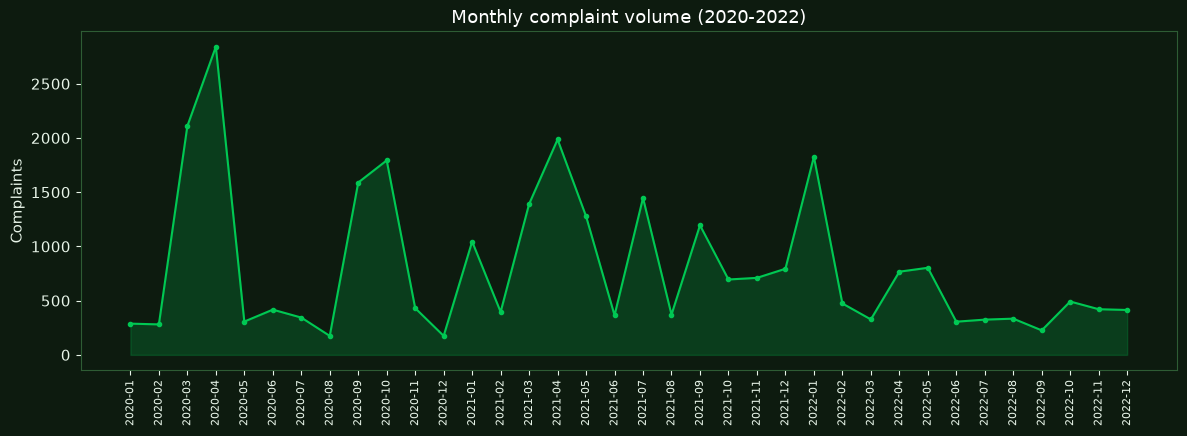

Peak month: 2020-04 with 2841 complaints


In [6]:
monthly = df.groupby("YearMonth").size()

plt.figure(figsize=(12, 4.5))
plt.plot(monthly.index.astype(str), monthly.values, color=GREENS[0], marker="o", markersize=3)
plt.fill_between(range(len(monthly)), monthly.values, color=GREENS[0], alpha=0.2)
plt.xticks(rotation=90, fontsize=8)
plt.title("Monthly complaint volume (2020-2022)", color="white")
plt.ylabel("Complaints")
plt.tight_layout()
plt.savefig("01_monthly_trend.png", dpi=150)
plt.show()

print("Peak month:", monthly.idxmax(), "with", monthly.max(), "complaints")


### 5.2 Disaster type breakdown (COBRADE category)

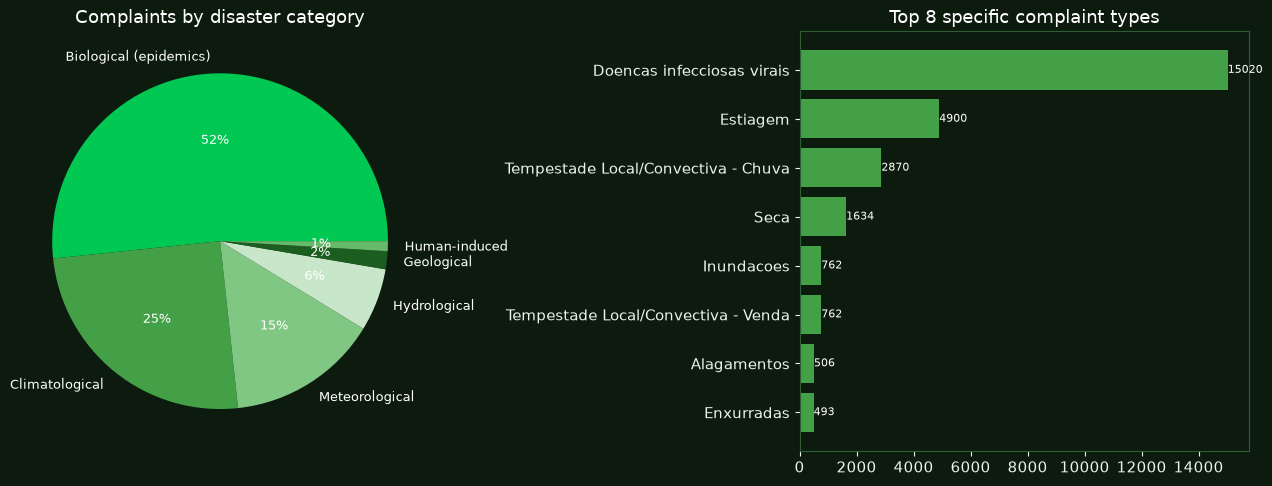

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(category_counts.values, labels=category_counts.index, autopct="%.0f%%",
            colors=GREENS, textprops={"color": "white", "fontsize": 9})
axes[0].set_title("Complaints by disaster category", color="white")

top_complaints = df["Complaint"].value_counts().head(8)
top_complaints_short = [c.split(" - ", 1)[-1][:35] for c in top_complaints.index]
bars = axes[1].barh(top_complaints_short[::-1], top_complaints.values[::-1], color=GREENS[1])
axes[1].bar_label(bars, color="white", fontsize=8)
axes[1].set_title("Top 8 specific complaint types", color="white")

plt.tight_layout()
plt.savefig("02_disaster_types.png", dpi=150)
plt.show()


### 5.3 Geographic distribution

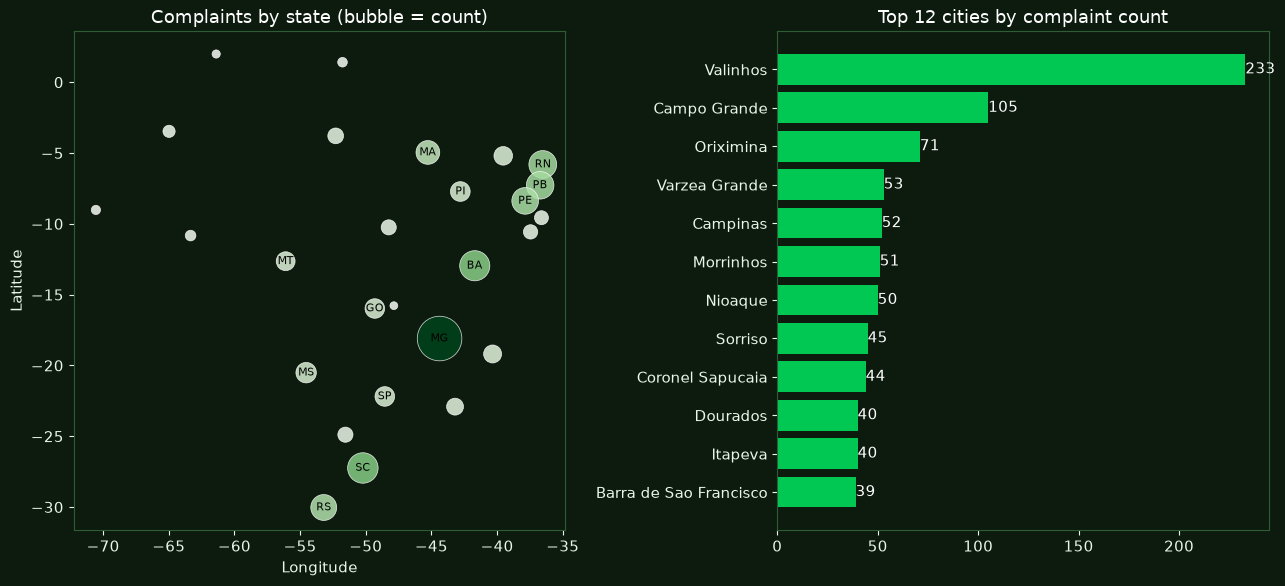

In [8]:
STATE_CENTROIDS = {
    "AC": (-70.55, -9.02), "AL": (-36.62, -9.57), "AP": (-51.77, 1.41),
    "AM": (-64.98, -3.47), "BA": (-41.70, -12.96), "CE": (-39.53, -5.20),
    "DF": (-47.86, -15.78), "ES": (-40.34, -19.19), "GO": (-49.31, -15.98),
    "MA": (-45.27, -4.96), "MT": (-56.10, -12.64), "MS": (-54.54, -20.51),
    "MG": (-44.38, -18.10), "PA": (-52.29, -3.79), "PB": (-36.72, -7.28),
    "PR": (-51.55, -24.89), "PE": (-37.86, -8.38), "PI": (-42.80, -7.72),
    "RJ": (-43.20, -22.91), "RN": (-36.52, -5.81), "RS": (-53.20, -30.03),
    "RO": (-63.34, -10.83), "RR": (-61.39, 1.99), "SC": (-50.22, -27.24),
    "SP": (-48.55, -22.19), "SE": (-37.45, -10.57), "TO": (-48.25, -10.25),
}

state_counts = df["State"].value_counts()
lons = [STATE_CENTROIDS[s][0] for s in state_counts.index]
lats = [STATE_CENTROIDS[s][1] for s in state_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

sizes = 30 + (state_counts.values / state_counts.values.max()) * 1000
sc = axes[0].scatter(lons, lats, s=sizes, c=state_counts.values, cmap="Greens", alpha=0.85, edgecolors="white", linewidths=0.5)
for s, lon, lat, cnt in zip(state_counts.index, lons, lats, state_counts.values):
    if cnt > state_counts.values.max() * 0.15:
        axes[0].text(lon, lat, s, ha="center", va="center", fontsize=8, color="black")
axes[0].set_title("Complaints by state (bubble = count)", color="white")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

top_cities = df["City"].value_counts().head(12)
bars = axes[1].barh(top_cities.index[::-1], top_cities.values[::-1], color=GREENS[0])
axes[1].bar_label(bars, color="white")
axes[1].set_title("Top 12 cities by complaint count", color="white")

plt.tight_layout()
plt.savefig("03_geography.png", dpi=150)
plt.show()


### 5.4 Human impact — total vs. excluding COVID-19 reports

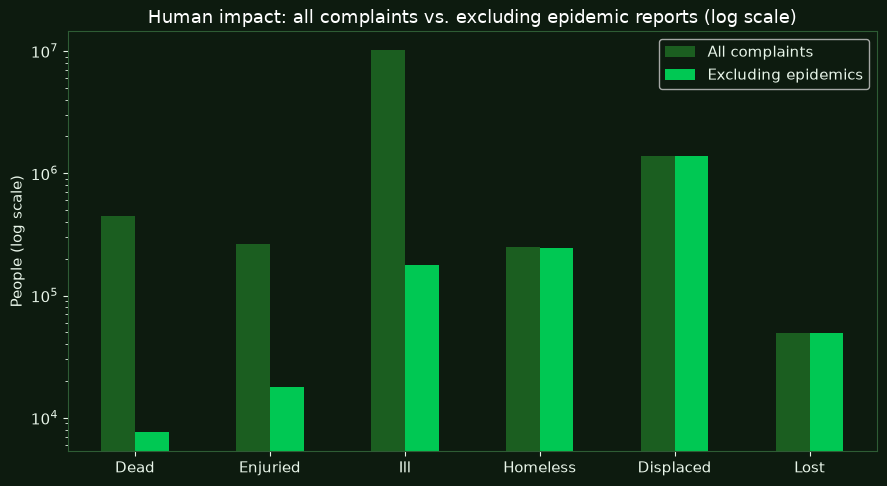

,All complaints,Excluding epidemics
Dead,446821,7662
Enjuried,261563,17851
Ill,10101440,176984
Homeless,247611,242484
Displaced,1386441,1385928
Lost,49407,49349


In [9]:
human_cols = ["Dead", "Enjuried", "Ill", "Homeless", "Displaced", "Lost"]
all_totals = df[human_cols].sum()
non_covid_totals = df.loc[df["Disaster_category"] != "Biological (epidemics)", human_cols].sum()

comparison = pd.DataFrame({"All complaints": all_totals, "Excluding epidemics": non_covid_totals})

fig, ax = plt.subplots(figsize=(9, 5))
comparison.plot(kind="bar", ax=ax, color=[GREENS[4], GREENS[0]], logy=True)
ax.set_title("Human impact: all complaints vs. excluding epidemic reports (log scale)", color="white")
ax.set_ylabel("People (log scale)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("04_human_impact.png", dpi=150)
plt.show()

comparison


### 5.5 Infrastructure damage by disaster category

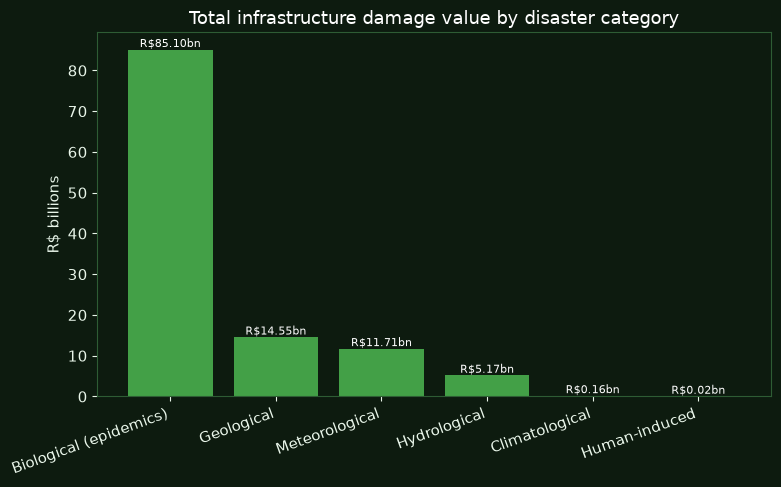

In [10]:
infra_by_cat = df.groupby("Disaster_category")[VALUE_COLS].sum().sum(axis=1).sort_values(ascending=False) / 1e9

plt.figure(figsize=(8, 5))
bars = plt.bar(infra_by_cat.index, infra_by_cat.values, color=GREENS[1])
plt.bar_label(bars, fmt="R$%.2fbn", color="white", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.title("Total infrastructure damage value by disaster category", color="white")
plt.ylabel("R$ billions")
plt.tight_layout()
plt.savefig("05_infra_by_category.png", dpi=150)
plt.show()


### 5.6 Environmental issues

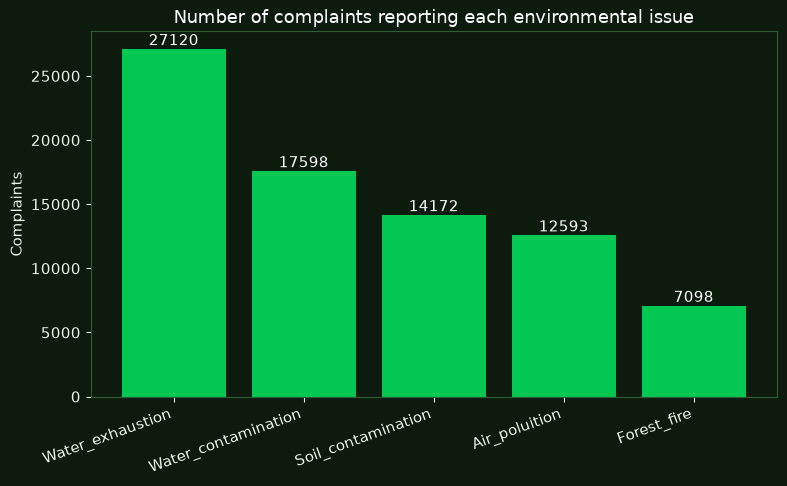

In [11]:
env_cols = ["Water_contamination", "Air_poluition", "Soil_contamination", "Water_exhaustion", "Forest_fire"]
env_prevalence = (df[env_cols] > 0).sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(env_prevalence.index, env_prevalence.values, color=GREENS[0])
plt.bar_label(bars, color="white")
plt.xticks(rotation=20, ha="right")
plt.title("Number of complaints reporting each environmental issue", color="white")
plt.ylabel("Complaints")
plt.tight_layout()
plt.savefig("06_environmental_issues.png", dpi=150)
plt.show()


### 5.7 Economic loss versus expenditure over time

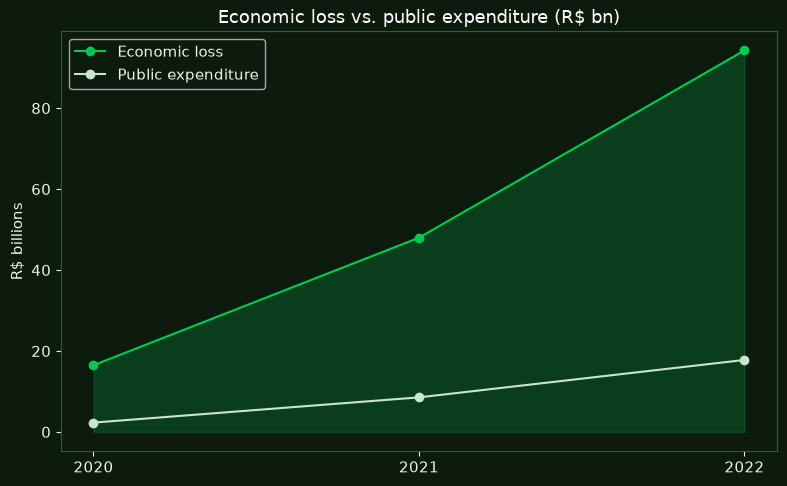

Loss-to-expenditure ratio by year:
Year
2020    7.2
2021    5.6
2022    5.3
dtype: float64


In [12]:
loss_by_year = df.groupby("Year")["Total_loss"].sum() / 1e9
exp_by_year = df.groupby("Year")["Total_expenditure"].sum() / 1e9

plt.figure(figsize=(8, 5))
plt.plot(loss_by_year.index, loss_by_year.values, marker="o", color=GREENS[0], label="Economic loss")
plt.plot(exp_by_year.index, exp_by_year.values, marker="o", color=GREENS[3], label="Public expenditure")
plt.fill_between(loss_by_year.index, loss_by_year.values, color=GREENS[0], alpha=0.2)
plt.title("Economic loss vs. public expenditure (R$ bn)", color="white")
plt.xticks(loss_by_year.index)
plt.ylabel("R$ billions")
plt.legend()
plt.tight_layout()
plt.savefig("07_loss_vs_expenditure.png", dpi=150)
plt.show()

ratio = (loss_by_year / exp_by_year).round(1)
print("Loss-to-expenditure ratio by year:")
print(ratio)


### 5.8 Correlation between key numeric variables

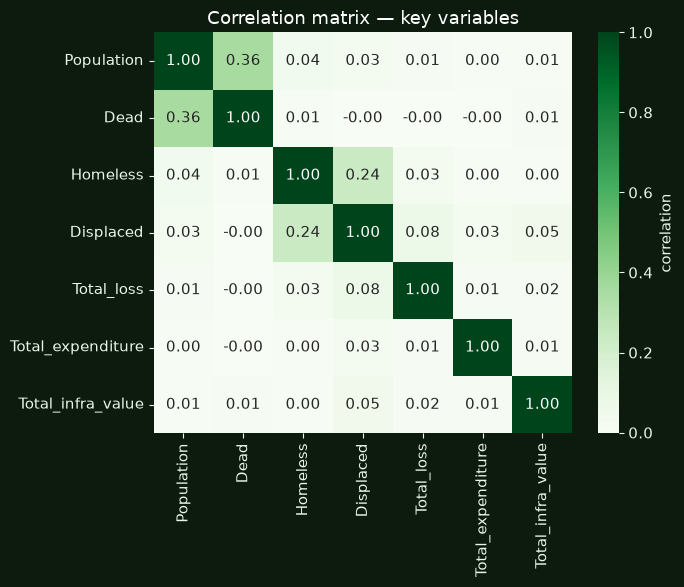

In [13]:
corr_cols = ["Population", "Dead", "Homeless", "Displaced", "Total_loss", "Total_expenditure", "Total_infra_value"]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greens", cbar_kws={"label": "correlation"})
plt.title("Correlation matrix — key variables", color="white")
plt.tight_layout()
plt.savefig("08_correlation.png", dpi=150)
plt.show()


### 5.9 Complaint status by disaster category

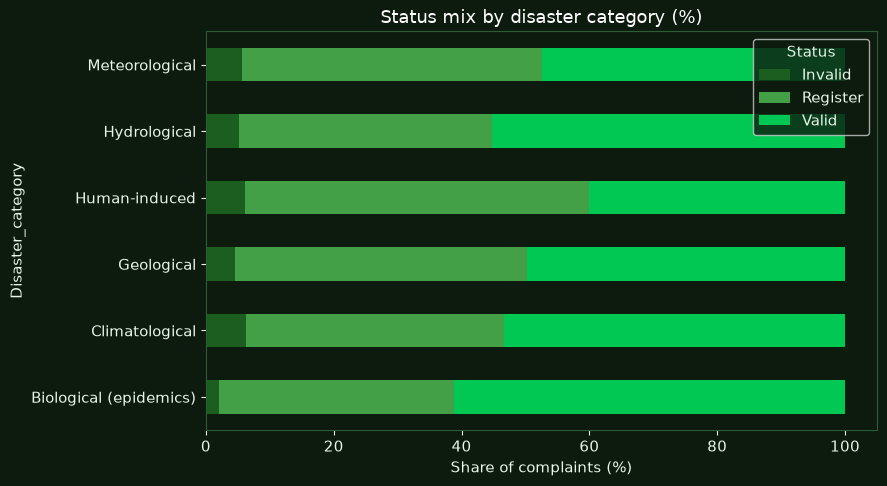

Status,Invalid,Register,Valid
Disaster_category,,,
Biological (epidemics),2.0,36.8,61.2
Climatological,6.3,40.4,53.3
Geological,4.6,45.7,49.7
Human-induced,6.1,53.8,40.1
Hydrological,5.2,39.5,55.3
Meteorological,5.7,46.9,47.4


In [14]:
status_by_cat = pd.crosstab(df["Disaster_category"], df["Status"], normalize="index") * 100

ax = status_by_cat[["Invalid", "Register", "Valid"]].plot(kind="barh", stacked=True, figsize=(9, 5), color=[GREENS[4], GREENS[1], GREENS[0]])
ax.set_title("Status mix by disaster category (%)", color="white")
ax.set_xlabel("Share of complaints (%)")
plt.tight_layout()
plt.savefig("09_status_by_category.png", dpi=150)
plt.show()

status_by_cat.round(1)


## 6. Predictive model: will a complaint be marked "Valid"?

In [15]:
model_df = df.copy()
model_df["Is_valid"] = (model_df["Status"] == "Valid").astype(int)

features = ["State", "Disaster_category", "Month", "Population"]
model_df = model_df.dropna(subset=features + ["Is_valid"])

X = model_df[features].copy()
y = model_df["Is_valid"]

encoders = {}
for col in ["State", "Disaster_category"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not Valid", "Valid"]))


Accuracy: 0.777

              precision    recall  f1-score   support

   Not Valid       0.74      0.76      0.75      3171
       Valid       0.81      0.79      0.80      4114

    accuracy                           0.78      7285
   macro avg       0.77      0.77      0.77      7285
weighted avg       0.78      0.78      0.78      7285



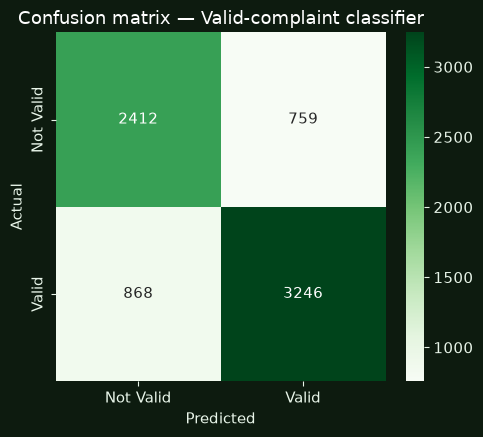

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Not Valid", "Valid"], yticklabels=["Not Valid", "Valid"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion matrix — Valid-complaint classifier", color="white")
plt.tight_layout()
plt.savefig("10_confusion_matrix.png", dpi=150)
plt.show()


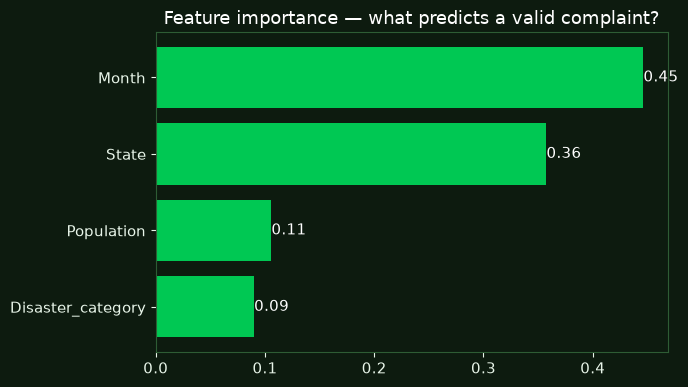

In [17]:
importances = pd.Series(clf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(7, 4))
bars = plt.barh(importances.index, importances.values, color=GREENS[0])
plt.bar_label(bars, fmt="%.2f", color="white")
plt.title("Feature importance — what predicts a valid complaint?", color="white")
plt.tight_layout()
plt.savefig("11_feature_importance.png", dpi=150)
plt.show()


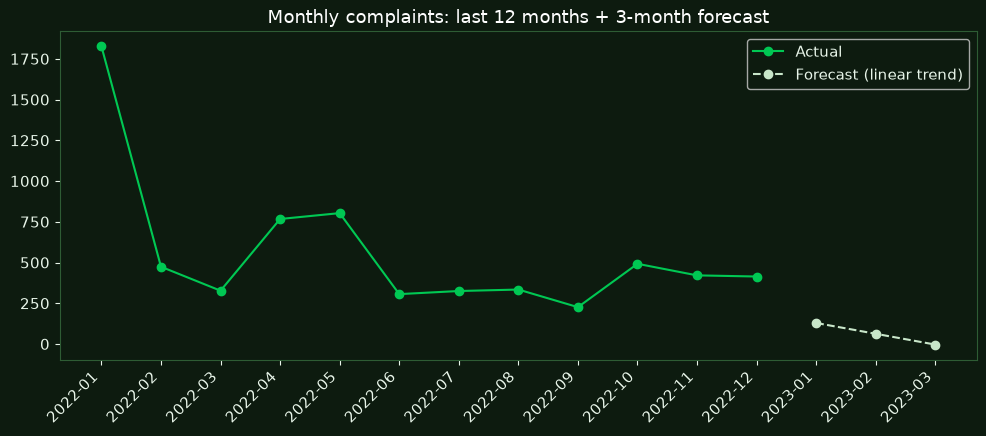

2023-01: ~129 complaints (forecast)
2023-02: ~63 complaints (forecast)
2023-03: ~0 complaints (forecast)


In [18]:
recent = monthly.tail(12)
x = np.arange(len(recent))
coeffs = np.polyfit(x, recent.values, 1)
trend = np.poly1d(coeffs)

future_x = np.arange(len(recent), len(recent) + 3)
future_labels = pd.period_range(recent.index[-1] + 1, periods=3, freq="M")
forecast = trend(future_x)

plt.figure(figsize=(10, 4.5))
plt.plot(recent.index.astype(str), recent.values, marker="o", color=GREENS[0], label="Actual")
plt.plot(future_labels.astype(str), forecast, marker="o", linestyle="--", color=GREENS[3], label="Forecast (linear trend)")
plt.xticks(rotation=45, ha="right")
plt.title("Monthly complaints: last 12 months + 3-month forecast", color="white")
plt.legend()
plt.tight_layout()
plt.savefig("12_forecast.png", dpi=150)
plt.show()

for lbl, val in zip(future_labels, forecast):
    print(f"{lbl}: ~{max(0, round(val))} complaints (forecast)")


## 7. Export a clean dataset.

In [19]:
export_cols = [
    "Date", "Year", "Month", "State", "City", "Complaint", "Disaster_category",
    "Status", "Population", "Dead", "Enjuried", "Ill", "Homeless", "Displaced", "Lost",
    "Total_loss", "Total_expenditure", "Total_infra_value",
] + env_cols

df[export_cols].to_csv("civil_defense_clean.csv", index=False)
print("Saved civil_defense_clean.csv:", df[export_cols].shape)


Saved civil_defense_clean.csv: (29140, 23)
